# MovieIQ — Predictive Analytics on Film Success


## Stage 0 — Problem Statement
A movie is successful when `revenue > budget`. The target is the binary column `success`.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance
import joblib

BASE = Path(".")

## Stage 1 — Data Preparation

In [2]:
df = pd.read_csv(BASE / "movies.csv")
df["genre_list"] = df["genres"].fillna("Unknown").apply(
    lambda x: [g for g in str(x).split("|") if g] or ["Unknown"]
)
df["success"] = (df["revenue"] > df["budget"]).astype(int)

print("Shape:", df.shape)
display(df.head())
display(df[["budget", "revenue", "popularity", "runtime", "vote_average"]].describe())
print("Missing values:")
print(df.isna().sum())
print("Success proportion:", df["success"].mean())

Shape: (2000, 9)


,budget,revenue,popularity,runtime,vote_average,title,genres,genre_list,success
0,57755036,107323371,60.377360,98,6.611888,Movie 1,"[{'id': 10749, 'name': 'Romance'}]","[[{'id': 10749, 'name': 'Romance'}]]",1
1,192100010,342896533,86.289857,96,7.184687,Movie 2,"[{'id': 18, 'name': 'Drama'}]","[[{'id': 18, 'name': 'Drama'}]]",1
2,128521863,253206827,86.995324,148,3.542978,Movie 3,"[{'id': 35, 'name': 'Comedy'}]","[[{'id': 35, 'name': 'Comedy'}]]",1
3,156299516,89635602,72.710096,118,5.985176,Movie 4,"[{'id': 18, 'name': 'Drama'}]","[[{'id': 18, 'name': 'Drama'}]]",0
4,148532820,221133868,74.829585,161,4.578480,Movie 5,"[{'id': 35, 'name': 'Comedy'}]","[[{'id': 35, 'name': 'Comedy'}]]",1


,budget,revenue,popularity,runtime,vote_average
count,2.000000e+03,2.000000e+03,2000.000000,2000.000000,2000.000000
mean,1.019211e+08,1.780574e+08,50.090738,129.568000,6.036764
std,5.682795e+07,1.293879e+08,28.482104,28.906507,1.743093
min,1.070640e+06,1.138729e+06,1.018466,80.000000,3.008133
25%,5.274832e+07,7.458306e+07,25.720784,104.000000,4.583298
50%,1.026023e+08,1.484882e+08,50.210396,130.000000,6.052901
75%,1.507962e+08,2.623679e+08,74.925354,155.000000,7.577305
max,1.999879e+08,5.744901e+08,99.764659,179.000000,8.998509


Missing values:
budget          0
revenue         0
popularity      0
runtime         0
vote_average    0
title           0
genres          0
genre_list      0
success         0
dtype: int64
Success proportion: 0.807


## Stage 2 — Exploratory Data Analysis

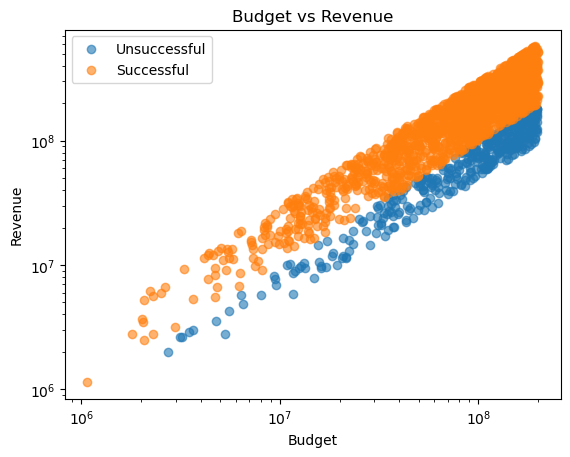

In [3]:
for label, group in df.groupby("success"):
    plt.scatter(group["budget"], group["revenue"], alpha=0.6,
                label="Successful" if label == 1 else "Unsuccessful")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.title("Budget vs Revenue")
plt.legend()
plt.show()

In [4]:
genre_df = df.assign(genre=df["genre_list"]).explode("genre")
genre_summary = genre_df.groupby("genre").agg(
    movie_count=("title", "count"),
    success_rate=("success", "mean")
).sort_values("movie_count", ascending=False)
display(genre_summary.head(15))
display(genre_summary[genre_summary["movie_count"] >= 20]
        .sort_values("success_rate", ascending=False).head(15))

,movie_count,success_rate
genre,,
"[{'id': 10749, 'name': 'Romance'}]",220,0.809091
"[{'id': 12, 'name': 'Adventure'}]",207,0.801932
"[{'id': 878, 'name': 'Science Fiction'}]",205,0.785366
"[{'id': 16, 'name': 'Animation'}]",203,0.812808
"[{'id': 35, 'name': 'Comedy'}]",202,0.811881
"[{'id': 27, 'name': 'Horror'}]",199,0.819095
"[{'id': 18, 'name': 'Drama'}]",197,0.822335
"[{'id': 53, 'name': 'Thriller'}]",194,0.809278
"[{'id': 28, 'name': 'Action'}]",192,0.786458


,movie_count,success_rate
genre,,
"[{'id': 18, 'name': 'Drama'}]",197,0.822335
"[{'id': 27, 'name': 'Horror'}]",199,0.819095
"[{'id': 16, 'name': 'Animation'}]",203,0.812808
[],181,0.812155
"[{'id': 35, 'name': 'Comedy'}]",202,0.811881
"[{'id': 53, 'name': 'Thriller'}]",194,0.809278
"[{'id': 10749, 'name': 'Romance'}]",220,0.809091
"[{'id': 12, 'name': 'Adventure'}]",207,0.801932
"[{'id': 28, 'name': 'Action'}]",192,0.786458


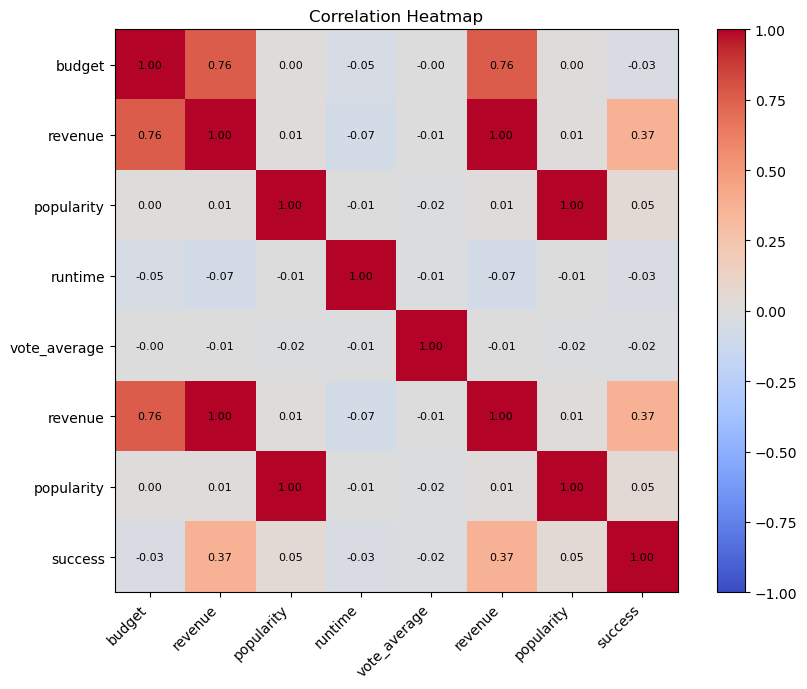

In [7]:
corr_cols = ["budget", "revenue", "popularity", "runtime",
             "vote_average", "revenue", "popularity", "success"]
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im)
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Stage 3 — Statistical Testing

In [8]:
successful = df.loc[df["success"] == 1, "popularity"]
unsuccessful = df.loc[df["success"] == 0, "popularity"]
t_stat, t_p = ttest_ind(successful, unsuccessful, equal_var=False)
print("Welch T-Test:", t_stat, t_p)

chi2, chi_p, dof, expected = chi2_contingency(
    pd.crosstab(genre_df["genre"], genre_df["success"])
)
print("Chi-Square:", chi2, chi_p, dof)

Welch T-Test: 2.0616702513558818 0.03968244490792032
Chi-Square: 1.7730811979406715 0.9945690204257113 9


## Stage 4 — Random Forest Model

Accuracy: 0.7775
Precision: 0.8111702127659575
Recall: 0.9442724458204335
F1: 0.8726752503576538
              precision    recall  f1-score   support

           0       0.25      0.08      0.12        77
           1       0.81      0.94      0.87       323

    accuracy                           0.78       400
   macro avg       0.53      0.51      0.50       400
weighted avg       0.70      0.78      0.73       400



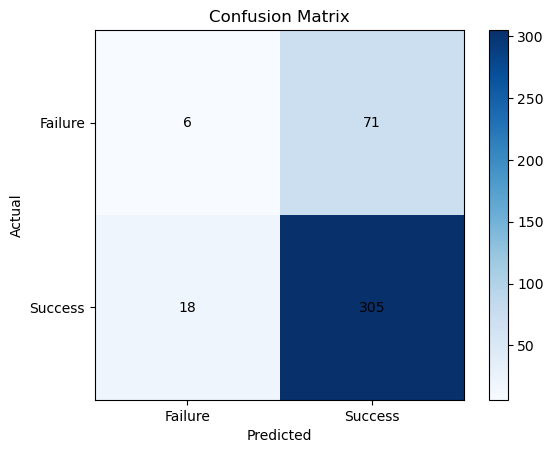

['movieiq_random_forest.joblib']

In [16]:
features = ["budget", "popularity", "runtime", "vote_average", "genres"]
X = df[features]
y = df["success"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

numeric = ["budget", "popularity", "runtime", "vote_average"]
categorical = ["genres"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1:", f1_score(y_test, pred))
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks([0, 1], ["Failure", "Success"])
plt.yticks([0, 1], ["Failure", "Success"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

joblib.dump(model, BASE / "movieiq_random_forest.joblib")

In [17]:
result = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)
importance = pd.DataFrame({
    "feature": features,
    "importance": result.importances_mean
}).sort_values("importance", ascending=False)
display(importance)

,feature,importance
2,runtime,0.01200
0,budget,0.00900
3,vote_average,0.00525
4,genres,0.00150
1,popularity,0.00050
